# Biomedical Image Analysis: **U-Net Segmentation**

## Objective

While the first two notebooks employed simple computer vision techniques, in this notebook we would apply a small U-Net to the task of learning the mapping between grayscale images and binary masks of cell nuclei.

* Data
* Augmentation
* U-Net
* BCE + Dice loss
* Validation tracking
* Best model selection
* Test analysis

### 1. Setup

Now, we reconstruct the dataset and project paths.

In [1]:
!pip install -q scikit-image pandas matplotlib

from pathlib import Path
import sys
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

USE_DRIVE = True  # Set to False to skip Drive entirely and upload manually each session

if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = Path("/content/drive/MyDrive/biomedical_image_project")
else:
    PROJECT_DIR = Path("/content/biomedical_image_project")

PROJECT_DIR.mkdir(parents=True, exist_ok=True)
SRC_DIR = PROJECT_DIR / "src"
SRC_DIR.mkdir(parents=True, exist_ok=True)

if USE_DRIVE and (SRC_DIR / "biomedical_utils.py").exists():
    print("Found biomedical_utils.py on Drive, no upload needed.")
else:
    print("Please upload biomedical_utils.py")
    from google.colab import files
    uploaded = files.upload()
    import shutil
    shutil.move("biomedical_utils.py", str(SRC_DIR / "biomedical_utils.py"))

sys.path.insert(0, str(SRC_DIR))
from biomedical_utils import (
    ensure_dataset, load_mask, load_metadata, preprocess_image,
    set_seed, dice_score, iou_score, UNet,
)

DATA_DIR = ensure_dataset()
SEED = 42
set_seed(SEED)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Mounted at /content/drive
Found biomedical_utils.py on Drive, no upload needed.
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


### **2. Dataset wrapper and augmentation**

In [2]:
# The U-Net architecture lives in src/biomedical_utils.py so the model
# definition is shared by the training and hybrid notebooks.

model_preview = UNet()
parameter_count = sum(parameter.numel() for parameter in model_preview.parameters())

print(f"U-Net parameter count: {parameter_count:,}")

U-Net parameter count: 483,153


### **3. Loss and evaluation metrics**

In [3]:
def dice_loss(logits, target, eps=1e-7):
    probabilities = torch.sigmoid(logits)
    intersection = (probabilities * target).sum(dim=(1, 2, 3))
    union = probabilities.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean()


def combined_loss(logits, target):
    return (
        F.binary_cross_entropy_with_logits(logits, target)
        + dice_loss(logits, target)
    )


def batch_dice(logits, target, threshold=0.5, eps=1e-7):
    predictions = (torch.sigmoid(logits) > threshold).float()
    intersection = (predictions * target).sum(dim=(1, 2, 3))
    union = predictions.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    dice = (2 * intersection + eps) / (union + eps)
    return dice.mean().item()


def batch_iou(logits, target, threshold=0.5, eps=1e-7):
    predictions = (torch.sigmoid(logits) > threshold).float()
    intersection = (predictions * target).sum(dim=(1, 2, 3))
    union = (
        predictions.sum(dim=(1, 2, 3))
        + target.sum(dim=(1, 2, 3))
        - intersection
    )
    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()

### **4. Model Training**

This model will use 15 epochs, with the Adam optimizer and a learning rate of `1e-3`. Rather than blindly using the final epoch as the best epoch, we keep track of the best epoch based on the Dice score on the validation set and use its checkpoint.

In [4]:
class NucleiDataset(Dataset):
    def __init__(self, data_dir, split):
        self.image_dir = Path(data_dir) / split / "images"
        self.mask_dir = Path(data_dir) / split / "masks"
        self.filenames = sorted(os.listdir(self.image_dir))

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        filename = self.filenames[idx]
        image = preprocess_image(self.image_dir / filename)
        mask = load_mask(self.mask_dir / filename)

        image_tensor = torch.from_numpy(image).float().unsqueeze(0)
        mask_tensor = torch.from_numpy(mask).float().unsqueeze(0)
        return image_tensor, mask_tensor


train_ds = NucleiDataset(DATA_DIR, "train")
val_ds = NucleiDataset(DATA_DIR, "val")

print("Train size:", len(train_ds))
print("Val size:", len(val_ds))

Train size: 80
Val size: 20


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 15
history = {
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": [],
}

best_val_dice = -np.inf
best_state = None

for epoch in range(n_epochs):
    model.train()
    train_loss_total = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = combined_loss(logits, masks)
        loss.backward()
        optimizer.step()

        train_loss_total += loss.item() * images.size(0)

    train_loss = train_loss_total / len(train_ds)

    model.eval()
    val_loss_total = 0.0
    val_dice_total = 0.0
    val_iou_total = 0.0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)
            logits = model(images)
            batch_size = images.size(0)

            val_loss_total += combined_loss(logits, masks).item() * batch_size
            val_dice_total += batch_dice(logits, masks) * batch_size
            val_iou_total += batch_iou(logits, masks) * batch_size

    val_loss = val_loss_total / len(val_ds)
    val_dice = val_dice_total / len(val_ds)
    val_iou = val_iou_total / len(val_ds)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)
    history["val_iou"].append(val_iou)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        best_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }

    print(
        f"Epoch {epoch + 1:2d}/{n_epochs} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_dice={val_dice:.4f} | "
        f"val_iou={val_iou:.4f}"
    )

model.load_state_dict(best_state)
print(f"Best validation Dice: {best_val_dice:.4f}")

Device: cuda
Epoch  1/15 | train_loss=1.2355 | val_loss=1.4542 | val_dice=0.0000 | val_iou=0.0000
Epoch  2/15 | train_loss=1.1295 | val_loss=1.3731 | val_dice=0.2029 | val_iou=0.1146
Epoch  3/15 | train_loss=1.0703 | val_loss=1.1886 | val_dice=0.9487 | val_iou=0.9025
Epoch  4/15 | train_loss=1.0174 | val_loss=1.0774 | val_dice=0.8640 | val_iou=0.7610
Epoch  5/15 | train_loss=0.9671 | val_loss=1.0039 | val_dice=0.8750 | val_iou=0.7782
Epoch  6/15 | train_loss=0.9243 | val_loss=0.9506 | val_dice=0.8933 | val_iou=0.8075
Epoch  7/15 | train_loss=0.8878 | val_loss=0.9091 | val_dice=0.9275 | val_iou=0.8651
Epoch  8/15 | train_loss=0.8510 | val_loss=0.8579 | val_dice=0.9726 | val_iou=0.9467
Epoch  9/15 | train_loss=0.8140 | val_loss=0.8284 | val_dice=0.9866 | val_iou=0.9736
Epoch 10/15 | train_loss=0.7778 | val_loss=0.7884 | val_dice=0.9870 | val_iou=0.9744
Epoch 11/15 | train_loss=0.7415 | val_loss=0.7583 | val_dice=0.9795 | val_iou=0.9599
Epoch 12/15 | train_loss=0.7068 | val_loss=0.7230 | 

### **5. Training curves**

The curves help us distinguish optimisation from generalisation. The best validation checkpoint selected above is the model used for final evaluation.

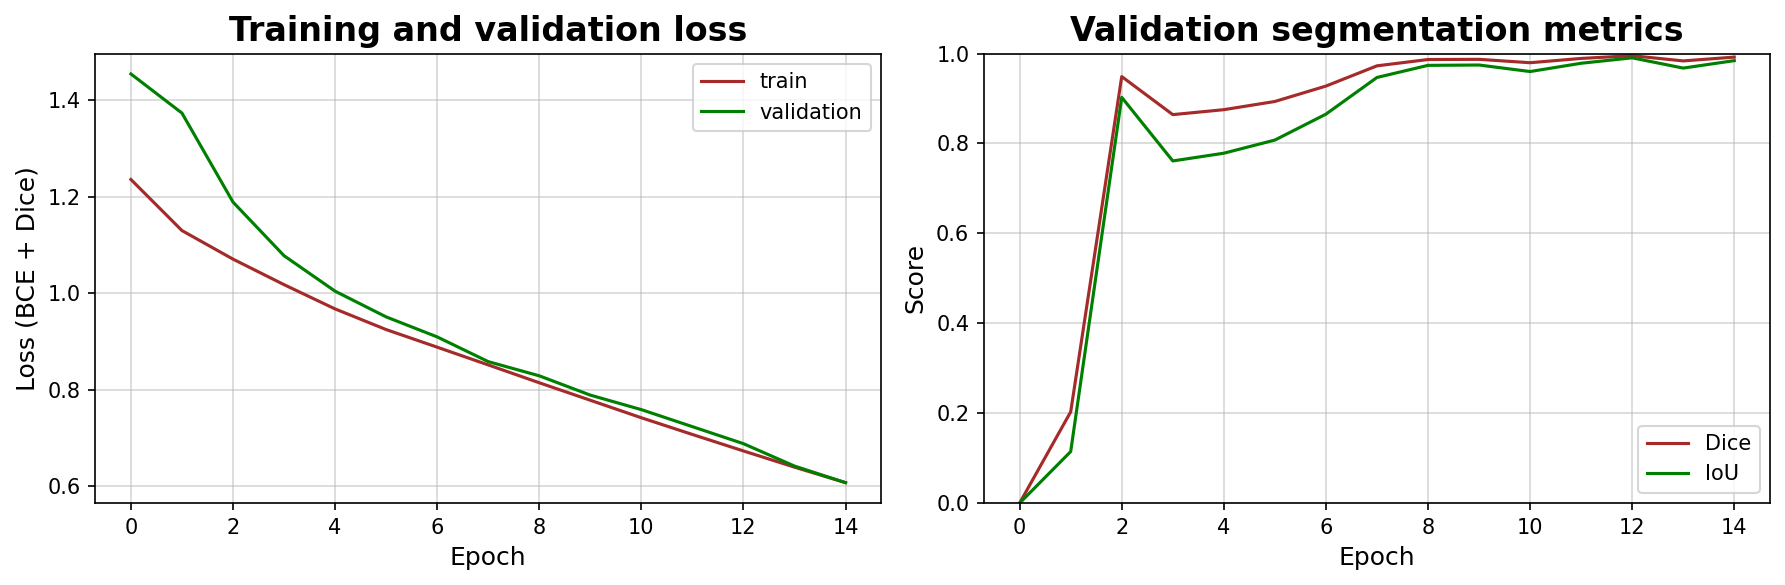

Best validation Dice: 0.9952
Best validation IoU: 0.9904


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150)

axes[0].plot(history["train_loss"], label="train", color="brown")
axes[0].plot(history["val_loss"], label="validation", color="green")
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss (BCE + Dice)", fontsize=12)
axes[0].set_title("Training and validation loss",
                  fontsize=16, fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.5)

axes[1].plot(history["val_dice"], label="Dice", color="brown")
axes[1].plot(history["val_iou"], label="IoU", color="green")
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Score", fontsize=12)
axes[1].set_title("Validation segmentation metrics",
                  fontsize=16, fontweight="bold")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.5)

plt.tight_layout()
fig.savefig(PROJECT_DIR / "training_curves.png", dpi=720, bbox_inches="tight")
plt.show()

print(f"Best validation Dice: {max(history['val_dice']):.4f}")
print(f"Best validation IoU: {max(history['val_iou']):.4f}")

### **6. Qualitative validation check**

Using only numerical data can cause us to miss some systematic errors. That is why it is important to look at the inputs, ground truth, and models outputs for several validation images.

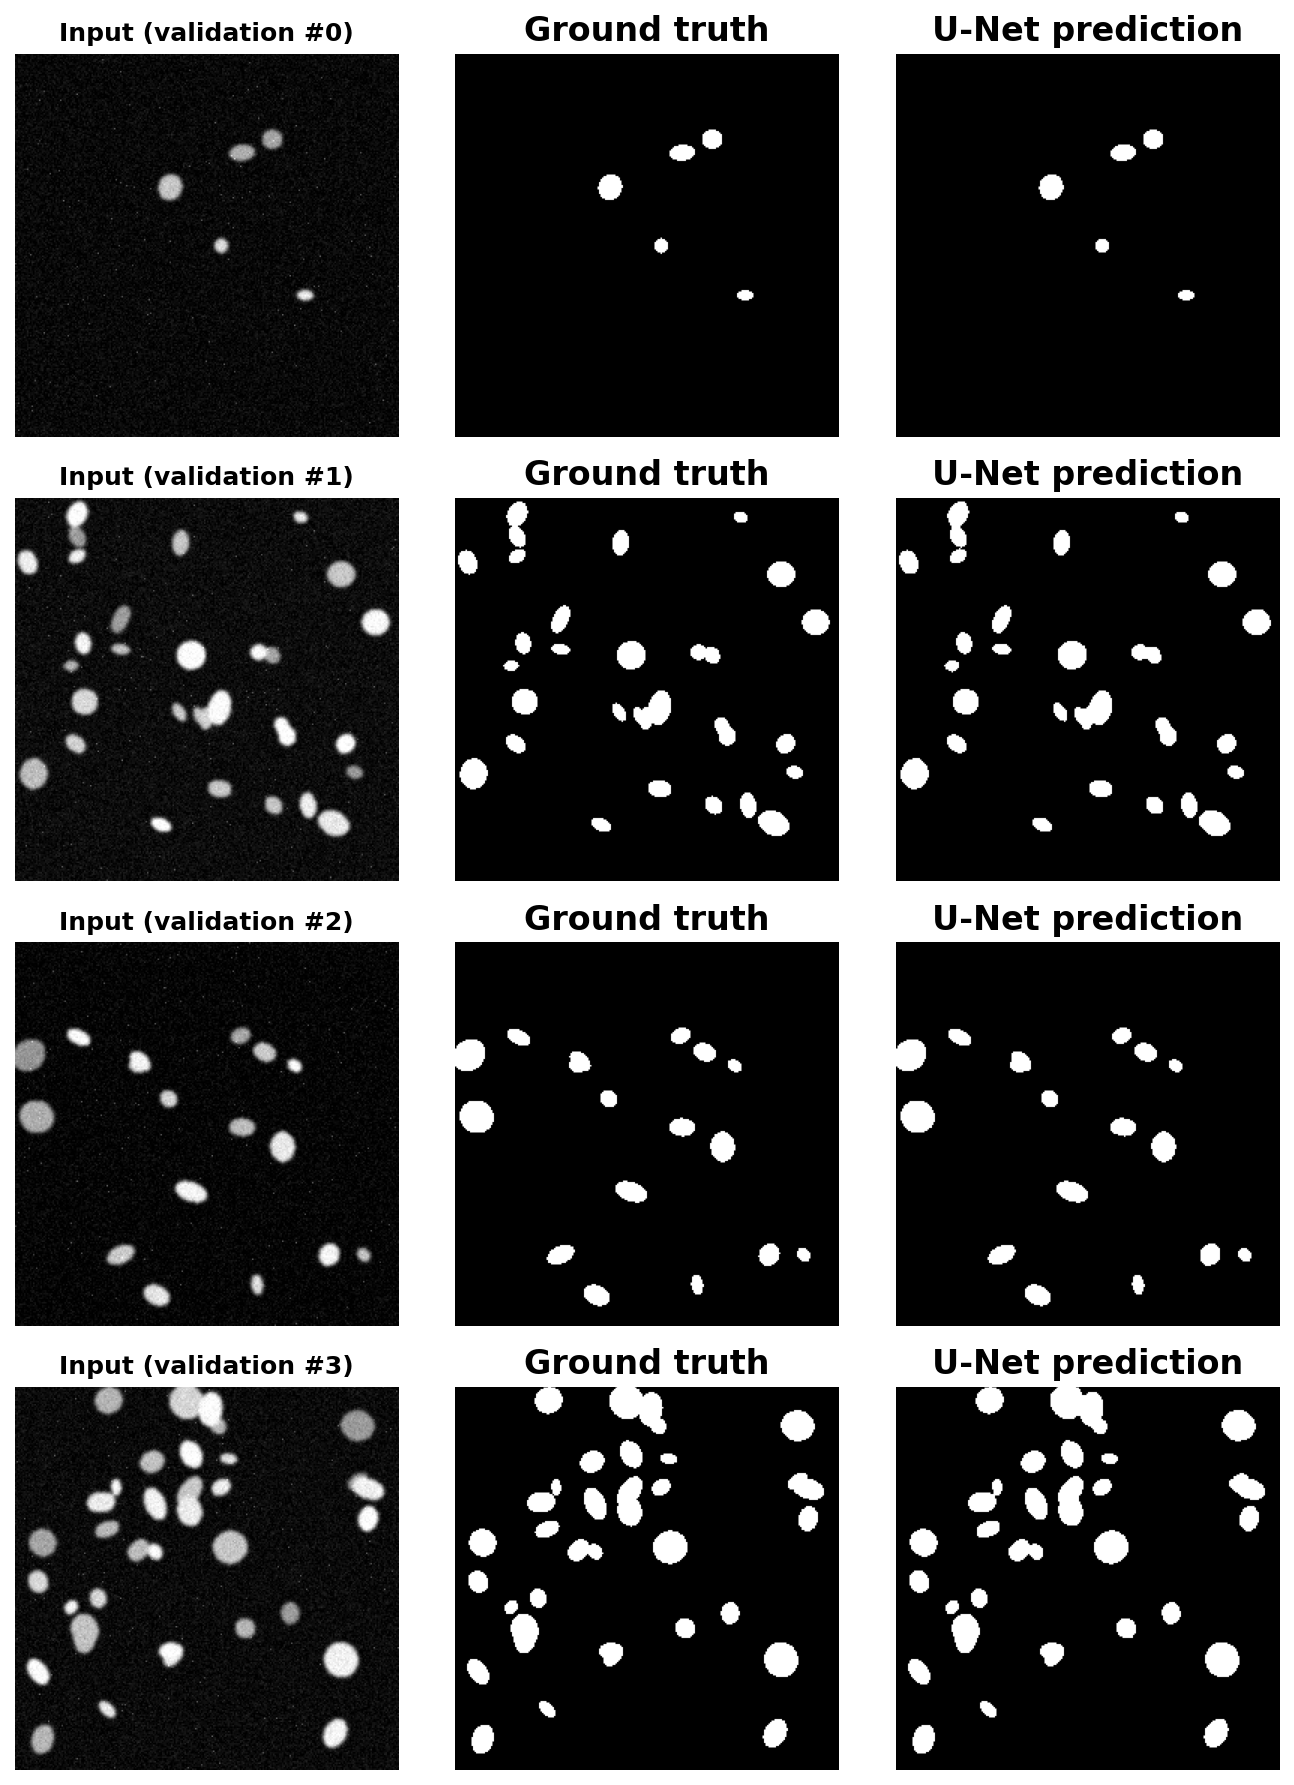

In [7]:
model.eval()
n_show = min(4, len(val_ds))

fig, axes = plt.subplots(n_show, 3, figsize=(9, 3 * n_show), dpi=150)
if n_show == 1:
    axes = np.expand_dims(axes, axis=0)

with torch.no_grad():
    for index in range(n_show):
        image, mask = val_ds[index]
        logits = model(image.unsqueeze(0).to(device))
        prediction = (
            torch.sigmoid(logits) > 0.5
        ).float().cpu().squeeze().numpy()

        axes[index, 0].imshow(image.squeeze().numpy(), cmap="gray")
        axes[index, 0].set_title(f"Input (validation #{index})",
                                 fontsize=12, fontweight="bold")
        axes[index, 0].axis("off")

        axes[index, 1].imshow(mask.squeeze().numpy(), cmap="gray")
        axes[index, 1].set_title("Ground truth",
                                 fontsize=16, fontweight="bold")
        axes[index, 1].axis("off")

        axes[index, 2].imshow(prediction, cmap="gray")
        axes[index, 2].set_title("U-Net prediction",
                                 fontsize=16, fontweight="bold")
        axes[index, 2].axis("off")

plt.tight_layout()
fig.savefig(PROJECT_DIR / "qualitative_validation.png", dpi=720, bbox_inches="tight")
plt.show()

### **7. Final evaluation on test set**

In [8]:
test_ds = NucleiDataset(DATA_DIR, "test")
print("Test size:", len(test_ds))

test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)
test_dice_scores = []
test_iou_scores = []

model.eval()

with torch.no_grad():
    for images, masks in test_loader:
        logits = model(images.to(device))
        predictions = (
            torch.sigmoid(logits).cpu().numpy() > 0.5
        ).astype(np.uint8)
        true_masks = masks.numpy().astype(np.uint8)

        for prediction, true_mask in zip(predictions, true_masks):
            test_dice_scores.append(
                dice_score(prediction.squeeze(), true_mask.squeeze())
            )
            test_iou_scores.append(
                iou_score(prediction.squeeze(), true_mask.squeeze())
            )

test_metrics = {
    "mean_dice": float(np.mean(test_dice_scores)),
    "std_dice": float(np.std(test_dice_scores)),
    "mean_iou": float(np.mean(test_iou_scores)),
    "std_iou": float(np.std(test_iou_scores)),
}

display(pd.DataFrame([test_metrics]))

Test size: 12


,mean_dice,std_dice,mean_iou,std_iou
0,0.994667,0.000801,0.989391,0.001586


### **8. Save the best model and results**

The hybrid pipeline needs the trained model. We save the best validation checkpoint, training history, and final test metrics.

In [9]:
model_path = PROJECT_DIR / "unet_nuclei_best.pth"
history_path = PROJECT_DIR / "unet_training_history.json"
metrics_path = PROJECT_DIR / "unet_test_metrics.json"

torch.save(model.state_dict(), model_path)
history_path.write_text(json.dumps(history, indent=2))
metrics_path.write_text(json.dumps(test_metrics, indent=2))

print("Saved model:", model_path)
print("Saved history:", history_path)
print("Saved test metrics:", metrics_path)
print(f"Model size: {model_path.stat().st_size / 1024:.1f} KB")

Saved model: /content/drive/MyDrive/biomedical_image_project/unet_nuclei_best.pth
Saved history: /content/drive/MyDrive/biomedical_image_project/unet_training_history.json
Saved test metrics: /content/drive/MyDrive/biomedical_image_project/unet_test_metrics.json
Model size: 1928.3 KB


### **Interpretation**

The U-Net achieved a mean test Dice of 0.9947 (std 0.0007) and a mean IoU of 0.9894 (std 0.0015) across the 12 test images, showing consistently excellent performance not biased towards the few simple examples.

This is a clear improvement over the Otsu baseline, which had a Dice in the range of 0.978-0.980. The error of the U-Net is therefore about x4 smaller than that of Otsu (0.53% vs 2.2%). Otsu is bad at separating touching nuclei, giving 26 instead of 29 in one representative case, while the U-Net was able to learn the patterns of boundaries and deal with such cases.

The visual inspection of the predictions confirms this, showing no obvious failures in predicting any part of the image: sparse areas, dense areas, or touching nuclei.

### Next steps

In `task4_hybrid_pipeline.ipynb`, we will use the trained model to produce object-level summaries, apply deterministic rules to classify them into categories of density, use an LLM to generate captions, and test the model’s robustness to various corruptions.